# Evaluation Stage

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 335
TEST_MONTHS = 24
FORECAST_HORIZON = 36
CONFIDENCE_LEVEL = 0.75
CONFIDENCE_Z = 1.1503493803760083
MAPE_THRESHOLD = 20.0

## Evaluate Result

In [ ]:
TARGET_CONFIGS = {
    'Passenger': {
        'value_col': 'passengers',
        'domestic_path': 'dataset/domestic_pass_monthly.csv',
        'international_path': 'dataset/international_pass_monthly.csv',
        'unit_label': 'passengers',
        'business_priority': 'primary',
    },
    'Cargo': {
        'value_col': 'cargo',
        'domestic_path': 'dataset/domestic_cargo_monthly.csv',
        'international_path': 'dataset/international_cargo_monthly.csv',
        'unit_label': 'cargo volume',
        'business_priority': 'secondary extension',
    },
}
SERIES_ORDER = ['Domestic', 'International', 'Overall Brazil']
MODEL_END_DATE = pd.Timestamp('2025-12-01')
FINAL_COMPONENT_MODEL = 'SARIMAX'
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


def load_prepared_series(path, label, target_name, value_col):
    df = pd.read_csv(path)
    first_col = df.columns[0]
    if first_col == '' or first_col.startswith('Unnamed'):
        df = df.drop(columns=first_col)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df.sort_values('year_month').reset_index(drop=True)
    df = df[['year_month', value_col]].rename(columns={value_col: 'value'})
    df['series'] = label
    df['target'] = target_name
    return df


def engineer_features(df):
    feat = df[['year_month', 'value']].copy().sort_values('year_month').reset_index(drop=True)
    feat['month'] = feat['year_month'].dt.month
    feat['quarter'] = feat['year_month'].dt.quarter
    feat['year'] = feat['year_month'].dt.year
    feat['time_idx'] = np.arange(len(feat))
    feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
    feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

    for lag in [1, 3, 6, 12]:
        feat[f'lag_{lag}'] = feat['value'].shift(lag)

    for window in [3, 6, 12]:
        feat[f'roll_mean_{window}'] = feat['value'].shift(1).rolling(window).mean()

    feat['roll_std_6'] = feat['value'].shift(1).rolling(6).std()

    expanding = feat['value'].shift(1).expanding()
    feat['exp_mean'] = expanding.mean()
    feat['exp_std'] = expanding.std()
    feat['exp_min'] = expanding.min()
    feat['exp_max'] = expanding.max()

    return feat


def chronological_split(df, test_months=TEST_MONTHS):
    train = df.iloc[:-test_months].copy().reset_index(drop=True)
    test = df.iloc[-test_months:].copy().reset_index(drop=True)
    return train, test


def score_forecast(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return {
        'MAPE': mean_absolute_percentage_error(actual, predicted) * 100,
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
    }


def next_month_index(last_observed_date, periods):
    return pd.date_range(last_observed_date + pd.offsets.MonthBegin(1), periods=periods, freq='MS')


def seasonal_naive_forecast(train_df, horizon):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    last_season = train_df['value'].iloc[-12:].to_numpy(dtype=float)
    forecast_values = np.tile(last_season, int(np.ceil(horizon / 12)))[:horizon]
    forecast = pd.Series(forecast_values, index=forecast_index, name='forecast')

    fitted = train_df['value'].shift(12)
    residuals = (train_df['value'] - fitted).dropna()
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'parameters': {'season_length': 12},
    }


def ets_forecast(train_df, horizon):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    model = ExponentialSmoothing(
        train_df['value'],
        trend='add',
        damped_trend=True,
        seasonal='mul',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit(optimized=True, use_brute=True)

    forecast = model.forecast(horizon)
    forecast.index = forecast_index

    fitted = pd.Series(model.fittedvalues, index=train_df['year_month'])
    residuals = train_df['value'].reset_index(drop=True) - pd.Series(model.fittedvalues).reset_index(drop=True)
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'trend': 'add',
            'damped_trend': True,
            'seasonal': 'mul',
            'seasonal_periods': 12,
        },
    }


def sarimax_forecast(train_df, horizon, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    model = SARIMAX(
        train_df['value'],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    results = model.fit(disp=False)

    forecast_results = results.get_forecast(steps=horizon)
    forecast = forecast_results.predicted_mean
    forecast.index = forecast_index

    conf_int = forecast_results.conf_int(alpha=1 - CONFIDENCE_LEVEL)
    lower = conf_int.iloc[:, 0].clip(lower=0)
    upper = conf_int.iloc[:, 1]
    lower.index = forecast_index
    upper.index = forecast_index

    fitted = pd.Series(results.fittedvalues, index=train_df['year_month'])
    residuals = pd.Series(results.resid).dropna()

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'order': order,
            'seasonal_order': seasonal_order,
        },
    }


def build_feature_row(history, next_date):
    history = pd.Series(history, dtype=float)
    row = {
        'time_idx': len(history),
        'month': next_date.month,
        'quarter': next_date.quarter,
        'month_sin': np.sin(2 * np.pi * next_date.month / 12),
        'month_cos': np.cos(2 * np.pi * next_date.month / 12),
        'lag_1': history.iloc[-1],
        'lag_3': history.iloc[-3],
        'lag_6': history.iloc[-6],
        'lag_12': history.iloc[-12],
        'roll_mean_3': history.iloc[-3:].mean(),
        'roll_mean_6': history.iloc[-6:].mean(),
        'roll_mean_12': history.iloc[-12:].mean(),
        'roll_std_6': history.iloc[-6:].std(ddof=1),
        'exp_mean': history.mean(),
        'exp_std': history.std(ddof=1),
        'exp_min': history.min(),
        'exp_max': history.max(),
    }
    return row


def random_forest_forecast(train_df, horizon):
    supervised = engineer_features(train_df).dropna().reset_index(drop=True)
    x_train = supervised[ML_FEATURES]
    y_train = supervised['value']

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    model.fit(x_train, y_train)

    fitted = pd.Series(model.predict(x_train), index=supervised['year_month'])
    residuals = pd.Series(y_train.to_numpy() - fitted.to_numpy())

    history = train_df['value'].tolist()
    forecast_index = next_month_index(train_df['year_month'].iloc[-1], horizon)
    forecast_values = []

    for next_date in forecast_index:
        feature_row = pd.DataFrame([build_feature_row(history, next_date)])
        prediction = float(model.predict(feature_row[ML_FEATURES])[0])
        forecast_values.append(prediction)
        history.append(prediction)

    forecast = pd.Series(forecast_values, index=forecast_index, name='forecast')
    scale = residuals.std(ddof=1) if len(residuals) > 1 else 0
    lower = (forecast - CONFIDENCE_Z * scale).clip(lower=0)
    upper = forecast + CONFIDENCE_Z * scale

    return {
        'forecast': forecast,
        'lower': lower,
        'upper': upper,
        'residuals': residuals,
        'fitted': fitted,
        'parameters': {
            'n_estimators': 500,
            'max_depth': 8,
            'min_samples_leaf': 2,
        },
    }


ML_FEATURES = [
    'time_idx', 'month', 'quarter', 'month_sin', 'month_cos',
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_6', 'exp_mean', 'exp_std', 'exp_min', 'exp_max'
]
MODEL_BUILDERS = {
    'Seasonal Naive': seasonal_naive_forecast,
    'ETS': ets_forecast,
    'SARIMAX': sarimax_forecast,
    'Random Forest': random_forest_forecast,
}


def evaluate_all_models(dataset_collection):
    records = []
    prediction_store = {}

    for target_name, series_dict in dataset_collection.items():
        prediction_store[target_name] = {}
        for series_name, frame in series_dict.items():
            train_df, test_df = chronological_split(frame)
            prediction_store[target_name][series_name] = {}

            for model_name, builder in MODEL_BUILDERS.items():
                result = builder(train_df, len(test_df))
                metrics = score_forecast(test_df['value'], result['forecast'].to_numpy())
                records.append({
                    'target': target_name,
                    'series': series_name,
                    'model': model_name,
                    **metrics,
                })
                prediction_store[target_name][series_name][model_name] = {
                    'train': train_df,
                    'test': test_df,
                    'result': result,
                }

    metrics_df = pd.DataFrame(records).sort_values(['target', 'series', 'MAPE']).reset_index(drop=True)
    best_models = (
        metrics_df.sort_values(['target', 'series', 'MAPE'])
        .groupby(['target', 'series'], as_index=False)
        .first()
    )
    return metrics_df, best_models, prediction_store


def evaluate_final_selection(dataset_collection):
    final_records = []
    final_holdout_outputs = {}
    direct_overall_outputs = {}

    for target_name, series_dict in dataset_collection.items():
        final_holdout_outputs[target_name] = {}

        component_forecasts = {}
        component_intervals = {}

        for series_name in ['Domestic', 'International']:
            train_df, test_df = chronological_split(series_dict[series_name])
            result = MODEL_BUILDERS[FINAL_COMPONENT_MODEL](train_df, len(test_df))
            forecast_df = pd.DataFrame({
                'year_month': test_df['year_month'],
                'actual_value': test_df['value'].values,
                'forecast_value': result['forecast'].values,
                'lower_75': result['lower'].values,
                'upper_75': result['upper'].values,
            })
            metrics = score_forecast(forecast_df['actual_value'], forecast_df['forecast_value'])
            final_records.append({
                'target': target_name,
                'series': series_name,
                'selected_model': FINAL_COMPONENT_MODEL,
                **metrics,
            })
            final_holdout_outputs[target_name][series_name] = {
                'model_name': FINAL_COMPONENT_MODEL,
                'forecast_df': forecast_df,
            }
            component_forecasts[series_name] = forecast_df[['year_month', 'forecast_value']].rename(columns={'forecast_value': f'forecast_{series_name.lower()}'})
            component_intervals[series_name] = forecast_df[['year_month', 'lower_75', 'upper_75']].rename(
                columns={'lower_75': f'lower_{series_name.lower()}', 'upper_75': f'upper_{series_name.lower()}'}
            )

        overall_train, overall_test = chronological_split(series_dict['Overall Brazil'])
        direct_overall_result = MODEL_BUILDERS[FINAL_COMPONENT_MODEL](overall_train, len(overall_test))
        direct_overall_outputs[target_name] = pd.DataFrame({
            'year_month': overall_test['year_month'],
            'actual_value': overall_test['value'].values,
            'forecast_value': direct_overall_result['forecast'].values,
            'lower_75': direct_overall_result['lower'].values,
            'upper_75': direct_overall_result['upper'].values,
        })

        coherent_forecast = overall_test[['year_month', 'value']].rename(columns={'value': 'actual_value'})
        coherent_forecast = coherent_forecast.merge(component_forecasts['Domestic'], on='year_month').merge(component_forecasts['International'], on='year_month')
        coherent_forecast = coherent_forecast.merge(component_intervals['Domestic'], on='year_month').merge(component_intervals['International'], on='year_month')
        coherent_forecast['forecast_value'] = coherent_forecast['forecast_domestic'] + coherent_forecast['forecast_international']
        coherent_forecast['lower_75'] = coherent_forecast['lower_domestic'] + coherent_forecast['lower_international']
        coherent_forecast['upper_75'] = coherent_forecast['upper_domestic'] + coherent_forecast['upper_international']
        coherent_forecast = coherent_forecast[['year_month', 'actual_value', 'forecast_value', 'lower_75', 'upper_75']]

        coherent_metrics = score_forecast(coherent_forecast['actual_value'], coherent_forecast['forecast_value'])
        final_records.append({
            'target': target_name,
            'series': 'Overall Brazil',
            'selected_model': 'Coherent sum of domestic and international SARIMAX forecasts',
            **coherent_metrics,
        })
        final_holdout_outputs[target_name]['Overall Brazil'] = {
            'model_name': 'Coherent sum of domestic and international SARIMAX forecasts',
            'forecast_df': coherent_forecast,
        }

    final_metrics_df = pd.DataFrame(final_records)
    return final_metrics_df, final_holdout_outputs, direct_overall_outputs


def build_future_forecasts(dataset_collection, horizon=FORECAST_HORIZON):
    rows = []
    for target_name, series_dict in dataset_collection.items():
        component_outputs = {}
        for series_name in ['Domestic', 'International']:
            result = MODEL_BUILDERS[FINAL_COMPONENT_MODEL](series_dict[series_name], horizon)
            component_outputs[series_name] = result
            forecast = result['forecast']
            rows.append({
                'target': target_name,
                'series': series_name,
                'year_1_average': forecast.iloc[:12].mean(),
                'year_3_average': forecast.iloc[-12:].mean(),
                'last_actual': series_dict[series_name]['value'].iloc[-1],
            })

        overall_forecast = component_outputs['Domestic']['forecast'] + component_outputs['International']['forecast']
        rows.append({
            'target': target_name,
            'series': 'Overall Brazil',
            'year_1_average': overall_forecast.iloc[:12].mean(),
            'year_3_average': overall_forecast.iloc[-12:].mean(),
            'last_actual': series_dict['Overall Brazil']['value'].iloc[-1],
        })

    future_summary = pd.DataFrame(rows)
    future_summary['year_1_vs_last_actual_pct'] = ((future_summary['year_1_average'] / future_summary['last_actual']) - 1) * 100
    future_summary['year_3_vs_last_actual_pct'] = ((future_summary['year_3_average'] / future_summary['last_actual']) - 1) * 100
    return future_summary


datasets = {}
summary_rows = []
excluded_rows = []

for target_name, config in TARGET_CONFIGS.items():
    domestic_raw = load_prepared_series(config['domestic_path'], 'Domestic', target_name, config['value_col'])
    international_raw = load_prepared_series(config['international_path'], 'International', target_name, config['value_col'])

    for series_name, raw_df in [('Domestic', domestic_raw), ('International', international_raw)]:
        dropped = raw_df[raw_df['year_month'] > MODEL_END_DATE].copy()
        if not dropped.empty:
            dropped['series'] = series_name
            dropped['target'] = target_name
            excluded_rows.append(dropped)

    domestic = domestic_raw[domestic_raw['year_month'] <= MODEL_END_DATE][['year_month', 'value']].copy()
    international = international_raw[international_raw['year_month'] <= MODEL_END_DATE][['year_month', 'value']].copy()
    overall = domestic.merge(international, on='year_month', how='inner', suffixes=('_domestic', '_international'))
    overall['value'] = overall['value_domestic'] + overall['value_international']
    overall = overall[['year_month', 'value']].copy()

    datasets[target_name] = {
        'Domestic': domestic,
        'International': international,
        'Overall Brazil': overall,
    }

    for series_name, frame in datasets[target_name].items():
        summary_rows.append({
            'target': target_name,
            'series': series_name,
            'start': frame['year_month'].min().date(),
            'end': frame['year_month'].max().date(),
            'rows': len(frame),
            'latest_value': frame['value'].iloc[-1],
        })

summary_df = pd.DataFrame(summary_rows)
excluded_summary = pd.concat(excluded_rows, ignore_index=True) if excluded_rows else pd.DataFrame()

print('Evaluation inputs after cleaning:')
display(summary_df)

if not excluded_summary.empty:
    print('Excluded row(s) before evaluation:')
    display(excluded_summary[['target', 'series', 'year_month', 'value']])

Evaluation inputs after cleaning:


,target,series,start,end,rows,latest_value
0,Passenger,Domestic,2008-01-01,2025-12-01,215,"8,729,241.00"
1,Passenger,International,2008-01-01,2025-12-01,215,"788,063.00"
2,Passenger,Overall Brazil,2008-01-01,2025-12-01,215,"9,517,304.00"
3,Cargo,Domestic,2008-01-01,2025-12-01,215,"34,188,162.00"
4,Cargo,International,2008-01-01,2025-12-01,216,"15,571,789.00"
5,Cargo,Overall Brazil,2008-01-01,2025-12-01,215,"49,759,951.00"


Excluded row(s) before evaluation:


,target,series,year_month,value
0,Passenger,Domestic,2026-01-01,52.00
1,Cargo,Domestic,2026-01-01,286.00


Best candidate model per target and series on the chronological holdout:


,target,series,model,MAPE,MAE,RMSE
0,Cargo,Domestic,SARIMAX,10.76,"3,647,693.59","4,241,566.26"
1,Cargo,International,Random Forest,17.40,"2,690,462.79","3,178,060.69"
2,Cargo,Overall Brazil,Random Forest,12.13,"5,973,867.76","6,644,718.05"
3,Passenger,Domestic,Random Forest,6.24,"515,168.52","670,576.68"
4,Passenger,International,SARIMAX,12.23,"89,026.14","103,639.90"
5,Passenger,Overall Brazil,Random Forest,6.66,"600,369.98","814,719.63"


Evaluation of the selected production-style models:


,target,series,selected_model,MAPE,MAE,RMSE,meets_mape_threshold,business_priority,approval_status
0,Passenger,Domestic,SARIMAX,7.11,"560,656.03","657,820.86",True,primary,Approved for current scope
1,Passenger,International,SARIMAX,12.23,"89,026.14","103,639.90",True,primary,Approved for current scope
2,Passenger,Overall Brazil,Coherent sum of domestic and international SAR...,7.22,"622,353.52","736,225.98",True,primary,Approved for current scope
3,Cargo,Domestic,SARIMAX,10.76,"3,647,693.59","4,241,566.26",True,secondary extension,Approved for current scope
4,Cargo,International,SARIMAX,20.77,"3,199,825.55","3,834,853.15",False,secondary extension,Needs another iteration
5,Cargo,Overall Brazil,Coherent sum of domestic and international SAR...,13.73,"6,751,587.09","7,781,882.17",True,secondary extension,Approved for current scope


Business-objective check for the primary project goal:


,target,series,selected_model,MAPE,meets_mape_threshold,objective_statement
2,Passenger,Overall Brazil,Coherent sum of domestic and international SAR...,7.22,True,Primary business objective: overall Brazil pas...


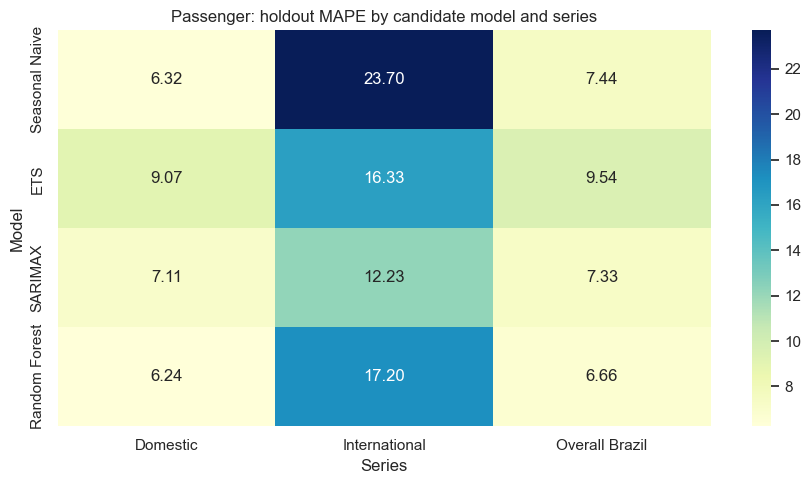

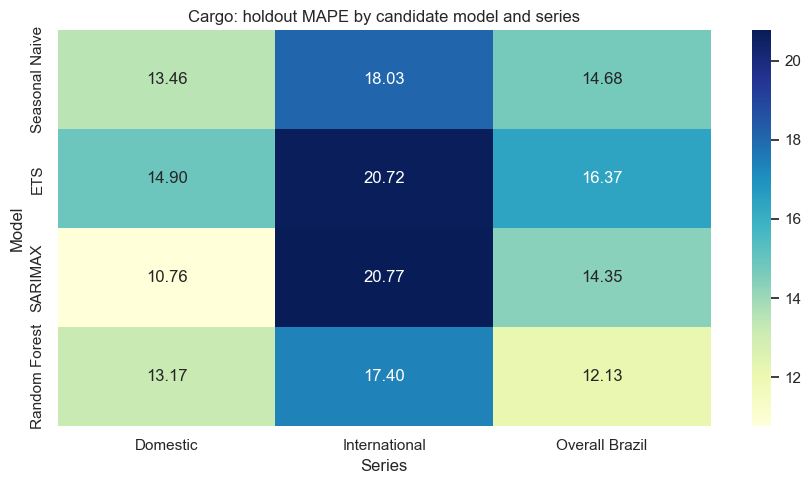

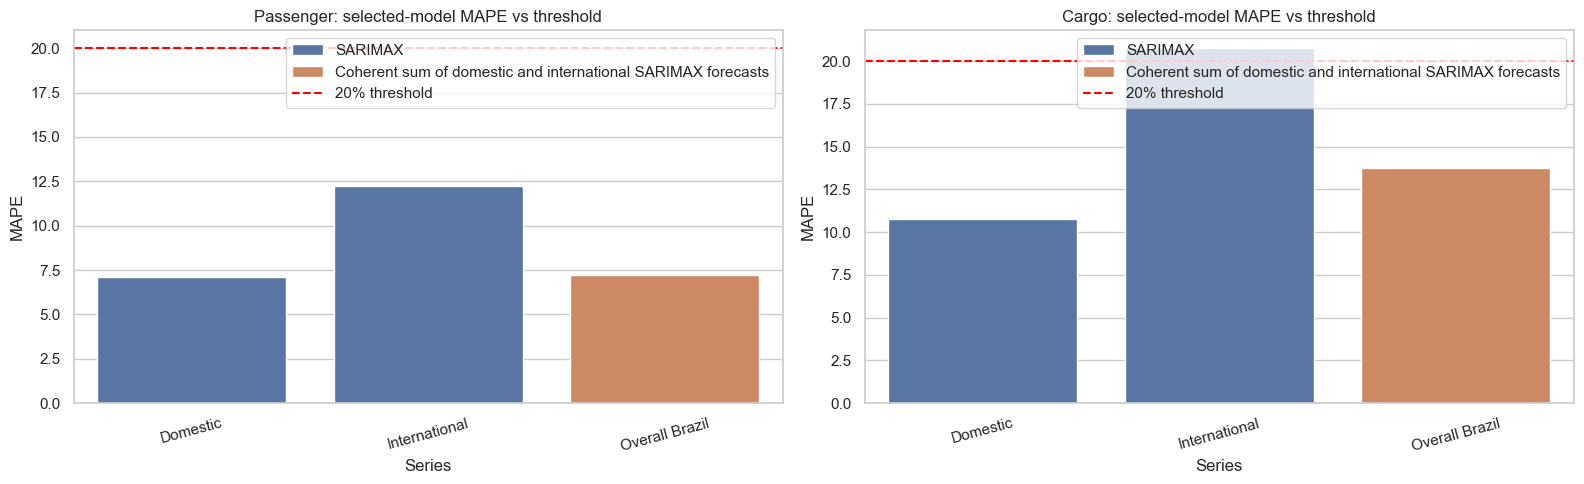

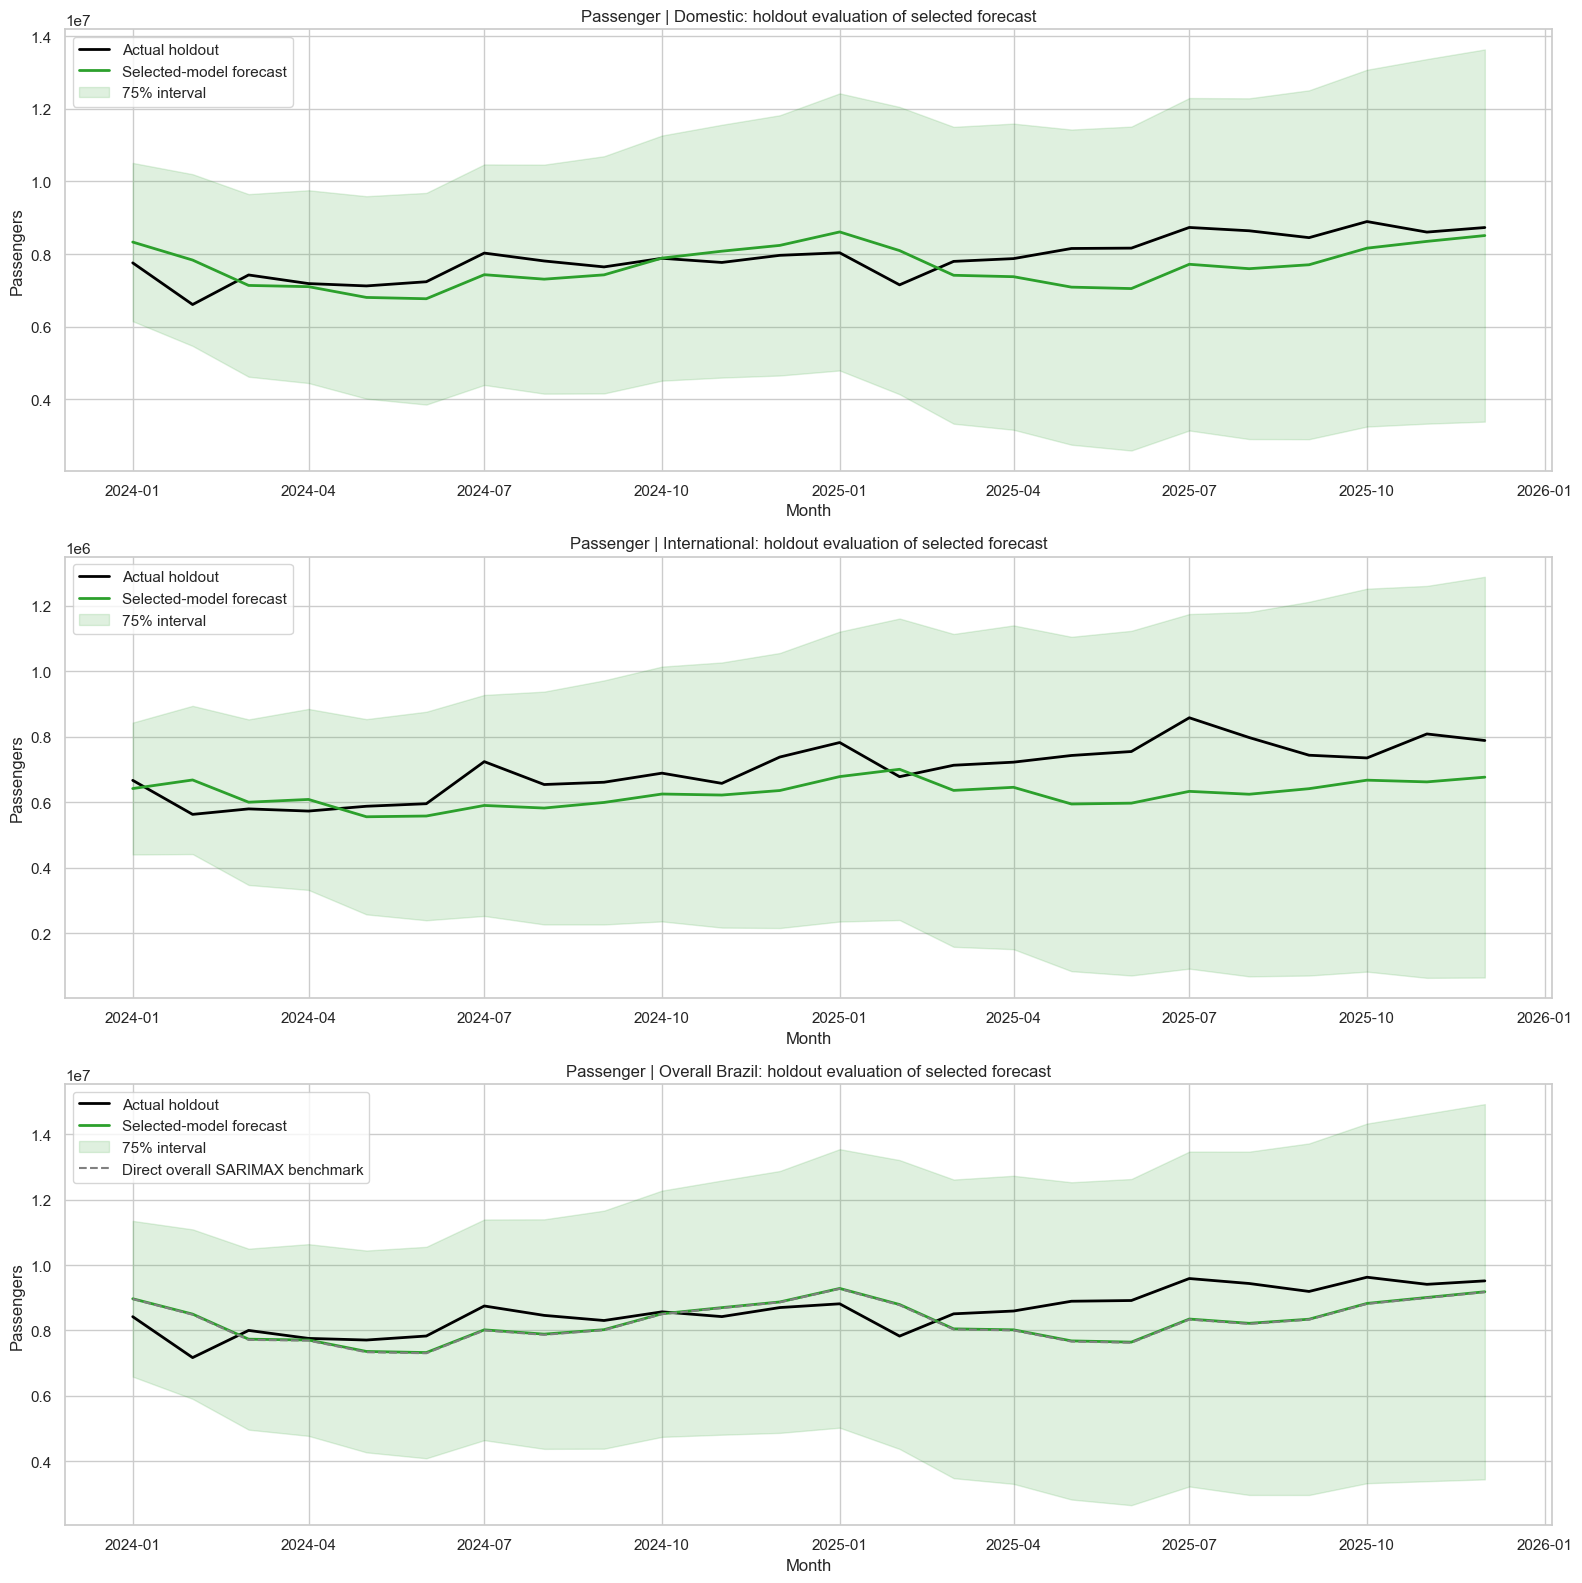

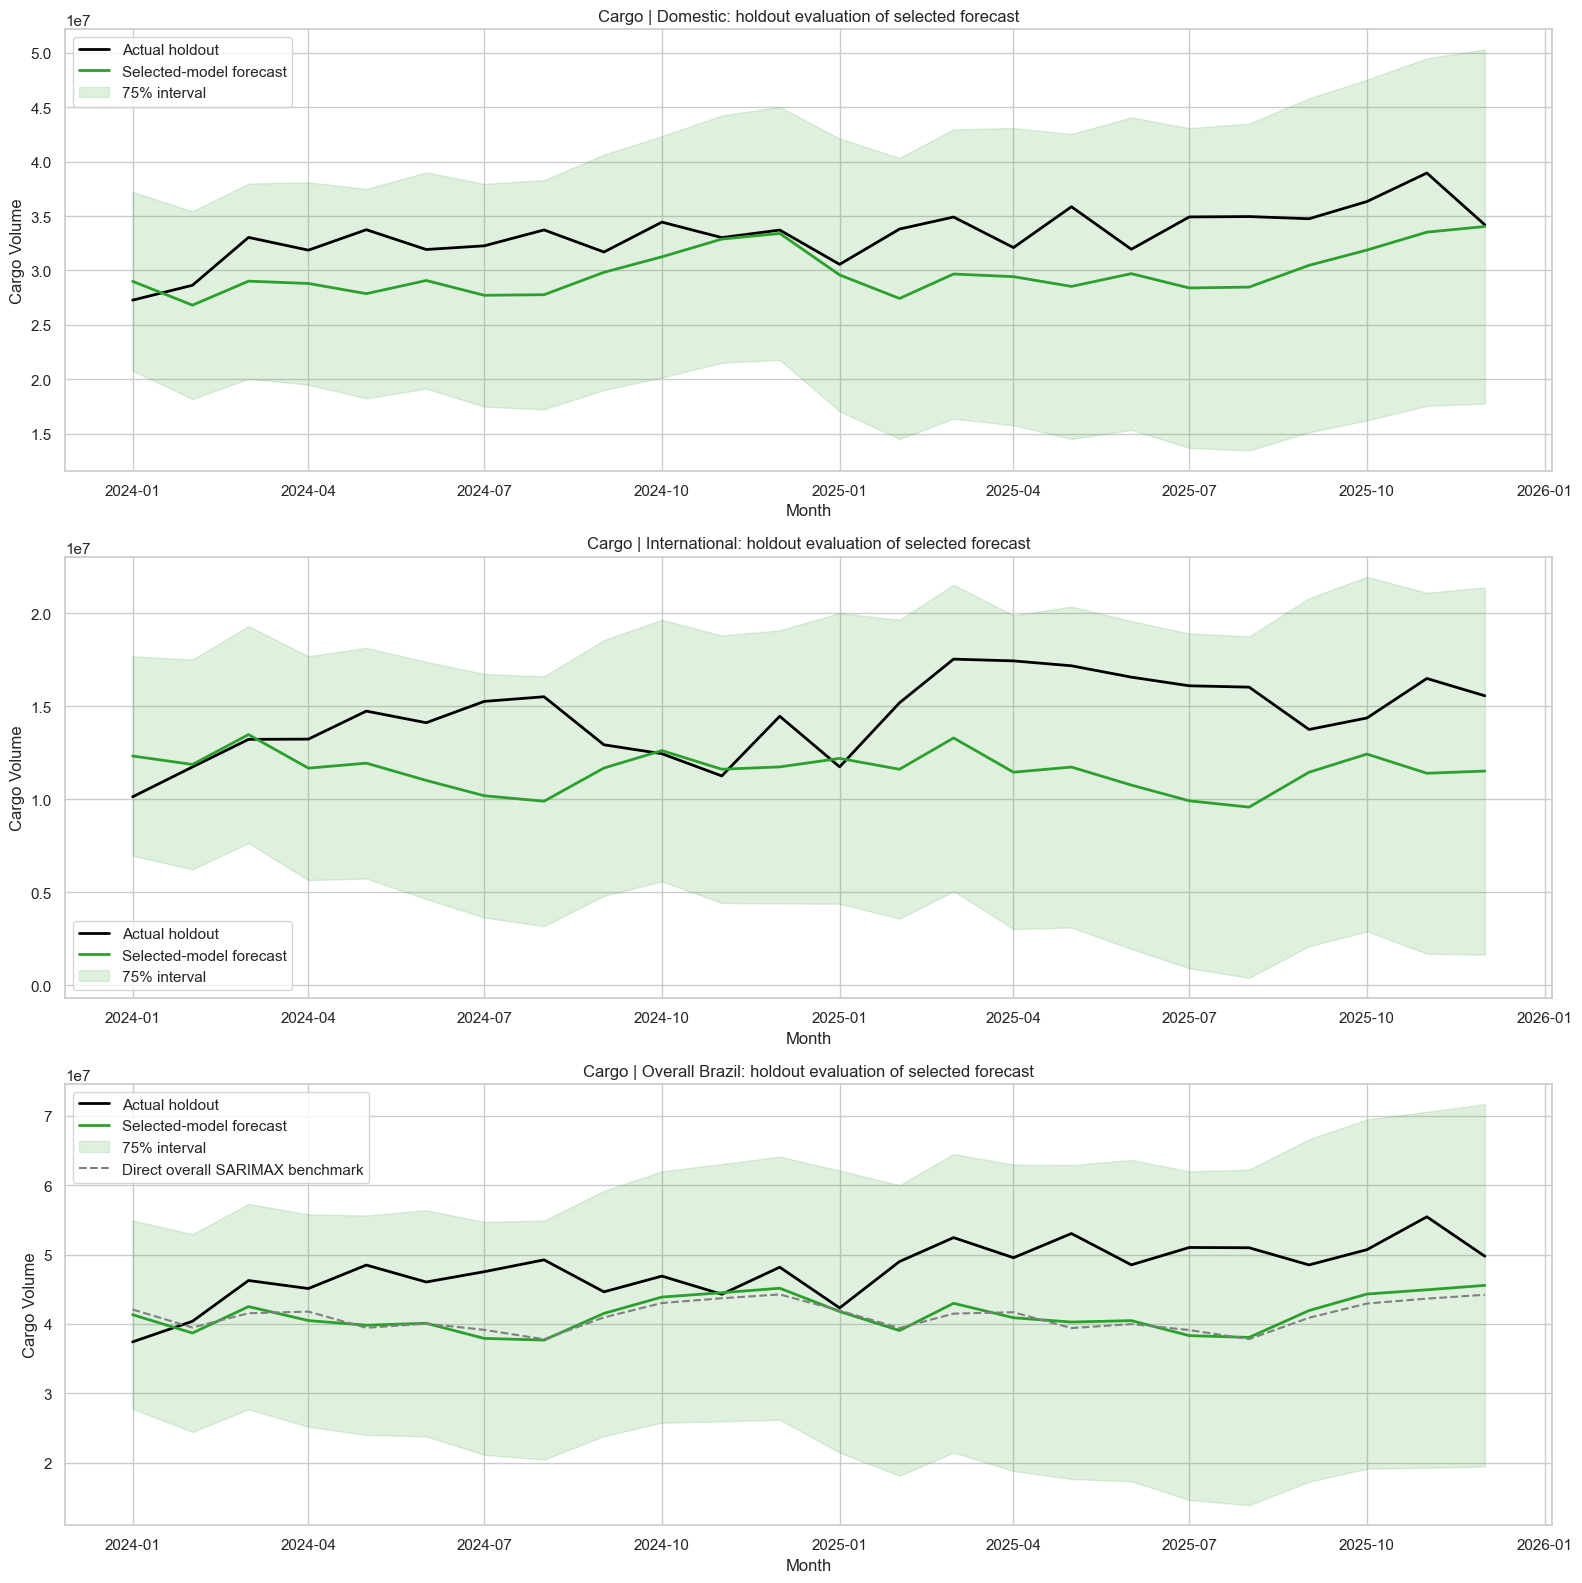

In [ ]:
metrics_df, best_models, prediction_store = evaluate_all_models(datasets)
final_metrics_df, final_holdout_outputs, direct_overall_outputs = evaluate_final_selection(datasets)
future_summary = build_future_forecasts(datasets)

approval_table = final_metrics_df.copy()
approval_table['meets_mape_threshold'] = approval_table['MAPE'].lt(MAPE_THRESHOLD)
approval_table['business_priority'] = approval_table['target'].map(lambda x: TARGET_CONFIGS[x]['business_priority'])
approval_table['approval_status'] = np.where(
    approval_table['meets_mape_threshold'],
    'Approved for current scope',
    'Needs another iteration',
)

objective_alignment = approval_table[(approval_table['target'] == 'Passenger') & (approval_table['series'] == 'Overall Brazil')].copy()
objective_alignment['objective_statement'] = 'Primary business objective: overall Brazil passenger traffic with MAPE below 20%.'

print('Best candidate model per target and series on the chronological holdout:')
display(best_models.round(2))

print('Evaluation of the selected production-style models:')
display(approval_table.round(2))

print('Business-objective check for the primary project goal:')
display(objective_alignment[['target', 'series', 'selected_model', 'MAPE', 'meets_mape_threshold', 'objective_statement']].round(2))

for target_name in TARGET_CONFIGS:
    target_metrics = metrics_df[metrics_df['target'] == target_name]
    metric_pivot = target_metrics.pivot(index='model', columns='series', values='MAPE').reindex(index=list(MODEL_BUILDERS.keys()), columns=SERIES_ORDER)

    plt.figure(figsize=(9, 5))
    sns.heatmap(metric_pivot, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title(f'{target_name}: holdout MAPE by candidate model and series')
    plt.xlabel('Series')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, target_name in zip(axes, TARGET_CONFIGS):
    target_final = approval_table[approval_table['target'] == target_name]
    sns.barplot(data=target_final, x='series', y='MAPE', hue='selected_model', ax=ax)
    ax.axhline(MAPE_THRESHOLD, color='red', linestyle='--', label='20% threshold')
    ax.set_title(f'{target_name}: selected-model MAPE vs threshold')
    ax.set_xlabel('Series')
    ax.set_ylabel('MAPE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend()

plt.tight_layout()
plt.show()

for target_name in TARGET_CONFIGS:
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))
    for ax, series_name in zip(axes, SERIES_ORDER):
        forecast_df = final_holdout_outputs[target_name][series_name]['forecast_df']
        ax.plot(forecast_df['year_month'], forecast_df['actual_value'], label='Actual holdout', color='black', linewidth=2)
        ax.plot(forecast_df['year_month'], forecast_df['forecast_value'], label='Selected-model forecast', color='tab:green', linewidth=2)
        ax.fill_between(forecast_df['year_month'], forecast_df['lower_75'], forecast_df['upper_75'], color='tab:green', alpha=0.15, label='75% interval')

        if series_name == 'Overall Brazil':
            direct_df = direct_overall_outputs[target_name]
            ax.plot(direct_df['year_month'], direct_df['forecast_value'], label='Direct overall SARIMAX benchmark', color='gray', linestyle='--')

        ax.set_title(f'{target_name} | {series_name}: holdout evaluation of selected forecast')
        ax.set_xlabel('Month')
        ax.set_ylabel(TARGET_CONFIGS[target_name]['unit_label'].title())
        ax.legend()

    plt.tight_layout()
    plt.show()

## Review Process

### Process Review Checklist

**Pass**
- **Dataset selection:** Dataset satisfies all criterias for Data Mining project: credibility, reliability, actuality.
- **Initial analysis:** We have produced Business Understanding in order to clarify what we are able to get from the dataset as well as what insight is useful from business perspective.
- **Data processing:** Full analysis of dataset was conducted. Data was cleaned and transformed for further modeling. At this point we assumed that cargo prediction might be useful for business purposes as well.
- **Model selection:** Several models were tested and SARIMAX was selected as the most reliable model in long-term predictions.
- **Business fit (primary target):** Overall Brazil passenger forecasting remains below the 20% MAPE threshold.
- **Using model to predict future metrics:** Reasonable predictionns were generated using chosen model. They cannot be evaluated right now.

**Review Needed**
- **Business fit (cargo):** Cargo extension is useful, but international cargo is weaker and should be monitored or iterated.
- **Feature scope:** Current model does not rely on any data except previous observations of target metric. We can potentially use other sources of information in order to streighten our predictions (like weather, political events, etc.)

### Process Review Conclusion

The core process is strong enough for a deployment-oriented transition of the passenger objective. Cargo forecasting is valuable but should be treated as a controlled extension while targeted improvements are implemented.

More features may be included in order to attempt to make predictions more accurate.

## Determine Next Steps

### List of Possible Actions

1. **Deploying passenger forecasting workflow**
   - Create user-friendly interface in order to allow more comfortable and yet customizable usage of produced model

3. **Finishing Cargo prediction functionality**
   - Optimizing current model or implementing a new one for predicting cargo traffic with better accuracy.

4. **Adding more features to training data**
   - Conducting an experiment if extra data will result better prediction quality

## Evaluation Summary

The evaluation supports the following conclusion:
- the project **meets its primary business objective** for overall passenger forecasting in Brazil,
- the current modeling workflow is methodologically sound enough to support a deployment-oriented next step,
- cargo forecasting adds useful planning value, but it should still be treated as a monitored extension rather than the final benchmark outcome,
- the most valuable next iteration is to strengthen validation and incorporate external drivers.
- adding more inputs to model might improve performance.